# Pharmaceutical Demand Forecasting & Anomaly Detection

This notebook builds a demand forecasting model for pharmaceutical sales using a combination of Prophet, LSTM, and XGBoost. The three models are blended using a Ridge regression meta-learner (stacking). It also includes anomaly detection on weekly sales using Isolation Forest.

**Dataset:** Pharma Sales Data by Milan Zdravković — [download from Kaggle](https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data)
Place `salesweekly.csv` in the same folder as this notebook before running.

**Note:** The dataset file is not included in this repository. Download it from the Kaggle link above.

**Goal:** Predict future drug demand to help pharmacies manage stock better and flag unusual sales patterns.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

## Setup
Setting a fixed random seed so results are reproducible every time the notebook runs.

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [3]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("/content/salesweekly.csv")

if not DATA_PATH.exists():
  raise FileNotFoundError(
      "Dataset not found. Please download 'salesweekly.csv' "
      "and place it in the 'data/' folder."
  )


## Loading the Data
Reading the CSV and doing a quick look at what the data contains.

In [4]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,1/5/2014,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,1/12/2014,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,1/19/2014,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,1/26/2014,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2/2/2014,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


In [5]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   datum   302 non-null    object 
 1   M01AB   302 non-null    float64
 2   M01AE   302 non-null    float64
 3   N02BA   302 non-null    float64
 4   N02BE   302 non-null    float64
 5   N05B    302 non-null    float64
 6   N05C    302 non-null    float64
 7   R03     302 non-null    float64
 8   R06     302 non-null    float64
dtypes: float64(8), object(1)
memory usage: 21.4+ KB


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,1/5/2014,14.00,11.67,21.300,185.950,41.0,0.0,32.0,7.0
1,1/12/2014,29.33,12.68,37.900,190.700,88.0,5.0,21.0,7.2
2,1/19/2014,30.67,26.34,45.900,218.400,80.0,8.0,29.0,12.0
3,1/26/2014,34.00,32.37,31.500,179.600,80.0,8.0,23.0,10.0
4,2/2/2014,31.02,23.35,20.700,159.880,84.0,12.0,29.0,12.0
5,2/9/2014,22.65,29.72,53.300,226.800,98.0,7.0,31.0,6.0
6,2/16/2014,33.33,30.69,47.300,320.700,89.0,14.0,18.0,16.2
7,2/23/2014,39.01,34.25,44.200,232.700,99.0,5.0,35.0,7.0
8,3/2/2014,36.68,28.75,40.355,222.500,52.0,2.0,16.0,10.1
9,3/9/2014,25.02,21.11,31.800,202.375,48.0,4.0,16.0,9.2


In [6]:
df['Date'] = pd.to_datetime(df['datum'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   datum   302 non-null    object        
 1   M01AB   302 non-null    float64       
 2   M01AE   302 non-null    float64       
 3   N02BA   302 non-null    float64       
 4   N02BE   302 non-null    float64       
 5   N05B    302 non-null    float64       
 6   N05C    302 non-null    float64       
 7   R03     302 non-null    float64       
 8   R06     302 non-null    float64       
 9   Date    302 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 23.7+ KB


In [7]:
df = df.sort_values(by='Date')

In [8]:
df.columns
print(df.columns.tolist())

['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Date']


## Preprocessing
The dataset has 8 separate drug category columns. I'm combining them into a single `Sales` column since the goal is forecasting total demand. Each category maps to a primary medicine — M01AB (Diclofenac), M01AE (Ibuprofen), N02BA (Aspirin), N02BE (Paracetamol), N05B (Diazepam), N05C (Zolpidem), R03 (Salbutamol), R06 (Cetirizine). Individual medicine-level data wasn't available, so forecasting is done at category level.

I have created a list named "drug_col" and created a new column named "Sales" which is the sum of all the drug columns.



In [9]:
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

df['Sales'] = df[drug_cols].sum(axis=1)




In [10]:
df_model = df[['Date', 'Sales']].copy()

In [11]:
df_model.isnull().sum()

,0
Date,0
Sales,0


## Exploratory Data Analysis
Plotting the full sales trend first, then zooming into the first 100 weeks to get a better look at short term patterns.

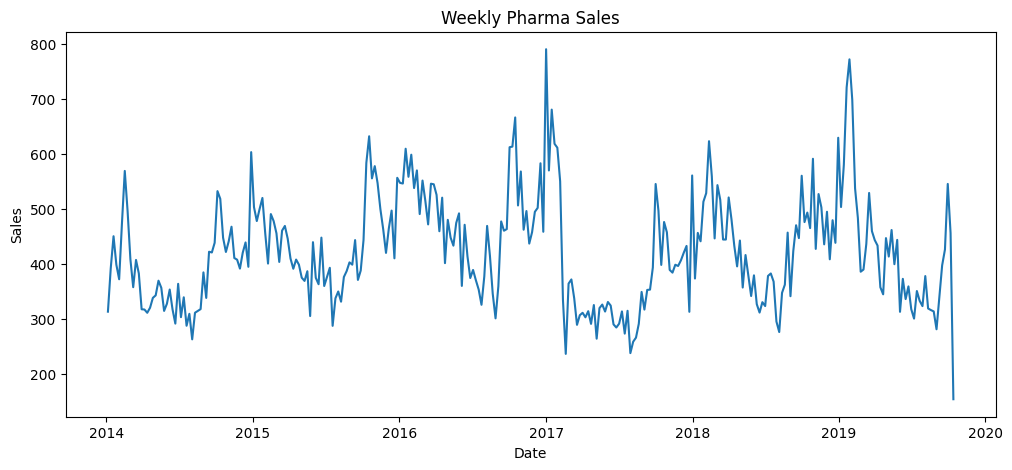

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_model['Date'], df_model['Sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Weekly Pharma Sales')
plt.show()

Text(0.5, 1.0, 'Zoomed Sales')

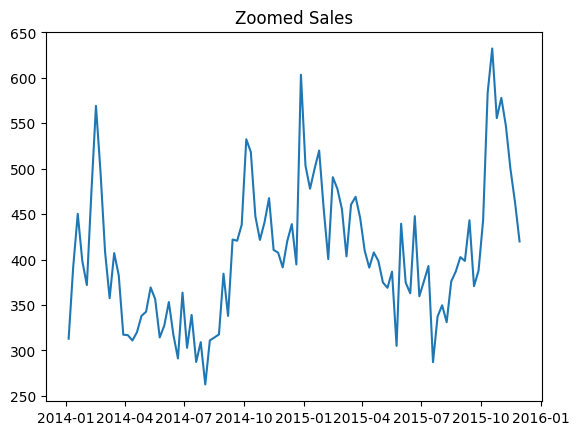

In [13]:
plt.plot(df_model['Date'][:100], df_model['Sales'][:100])
plt.title("Zoomed Sales")

### Smoothing & Log Transform
Raw sales data is noisy week to week. Applying a 4-week rolling average to smooth it out, then a log transform to stabilise the variance — large spikes affect models less after this.

In [14]:
df_model["Sales_smooth"] = df_model['Sales'].rolling(window=4).mean()

In [15]:
df_model.fillna(method='bfill', inplace=True)

/tmp/ipykernel_5795/1417483312.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_model.fillna(method='bfill', inplace=True)


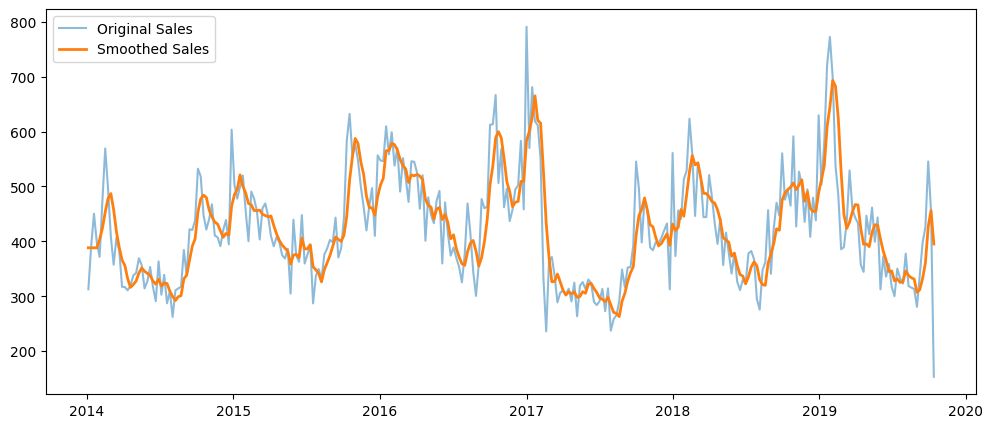

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df_model['Date'], df_model['Sales'], label='Original Sales', alpha=0.5)
plt.plot(df_model['Date'], df_model['Sales_smooth'], label='Smoothed Sales', linewidth=2)
plt.legend()
plt.show()

In [17]:
import numpy as np

df_model['Sales_log'] = np.log1p(df_model['Sales'])

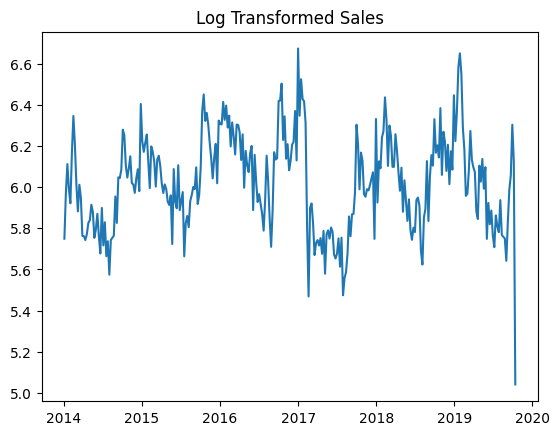

In [18]:
plt.plot(df_model['Date'], df_model['Sales_log'])
plt.title("Log Transformed Sales")
plt.show()

### Scaling
MinMaxScaler brings all values between 0 and 1. This is needed for the LSTM — neural networks are sensitive to input scale.

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df_model[['Sales_smooth']])

### Train / Test Split
Splitting 80% for training, 20% for testing. For time series this always has to be chronological — no shuffling, otherwise you'd be training on future data.

In [20]:
split_date = df_model['Date'].quantile(0.8)

train = df_model[df_model['Date'] <= split_date]
test = df_model[df_model['Date'] > split_date]

## Model 1 — Prophet
Prophet is a forecasting model by Meta designed for business time series. It's good at capturing long term trends and seasonal patterns (weekly, yearly). It needs the date column named `ds` and the target named `y`.

In [21]:
df_prophet_train = train[['Date', 'Sales']].copy()
df_prophet_train.columns = ['ds', 'y']

In [22]:
from prophet import Prophet

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_prophet.fit(df_prophet_train)

In [23]:
future = model_prophet.make_future_dataframe(periods=len(test), freq='w')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  dates = pd.date_range(


In [24]:
forecast = model_prophet.predict(future)

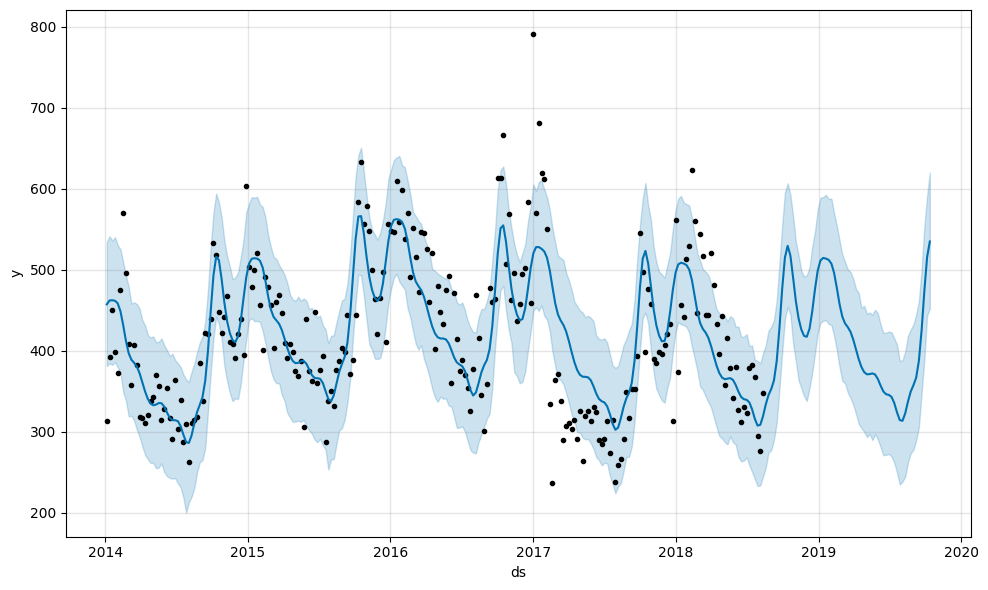

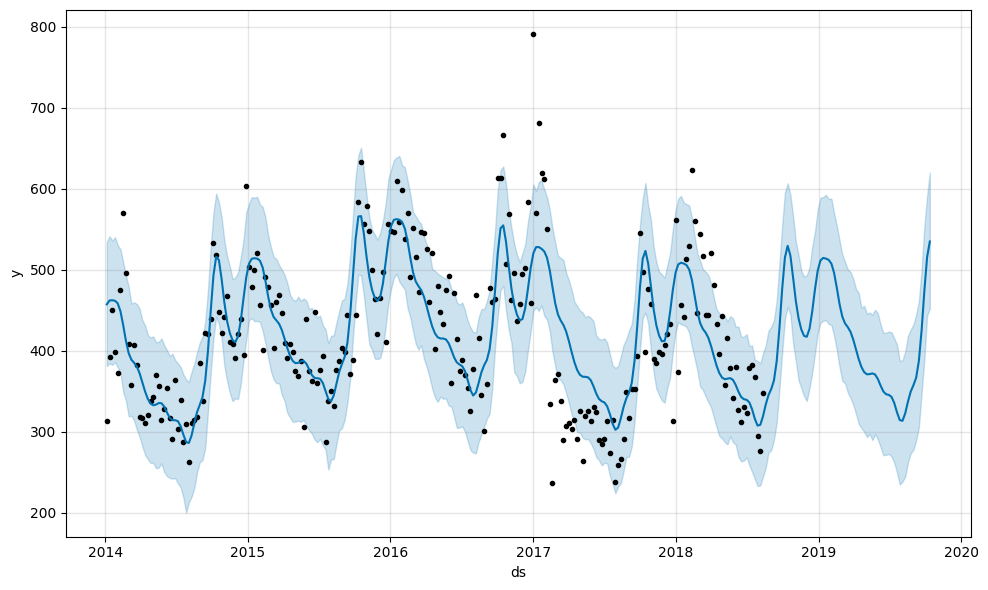

In [25]:
prophet_pred = forecast['yhat'][-len(test):].values
y_test_prophet = test['Sales'].values

model_prophet.plot(forecast)

In [26]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_prophet, prophet_pred)
print("Prophet MAE:", mae)

Prophet MAE: 58.54069497883253


## Model 2 — LSTM
LSTM (Long Short-Term Memory) is a type of recurrent neural network that has memory across time steps. Unlike regular neural networks, it remembers patterns across a sequence — useful for time series where recent history matters.

Each input is a sequence of 12 weeks of scaled sales data. The model learns to predict the next value from that sequence.

In [27]:
import numpy as np

def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(scaled_data)

In [28]:
split = int(0.8 * len(X_lstm))

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]

In [29]:
print(X_train_lstm.shape)

(232, 12, 1)


In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=16)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0663
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0292
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0243
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0232
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0217
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0205
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0191
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0177
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0164
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0154


In [31]:
lstm_pred = model_lstm.predict(X_test_lstm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step


In [32]:
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_lstm_actual = scaler.inverse_transform(y_test_lstm)


In [33]:
from sklearn.metrics import mean_absolute_error

mae_lstm = mean_absolute_error(y_test_lstm_actual, lstm_pred)
print("LSTM MAE:", mae_lstm)

LSTM MAE: 45.974501629050394


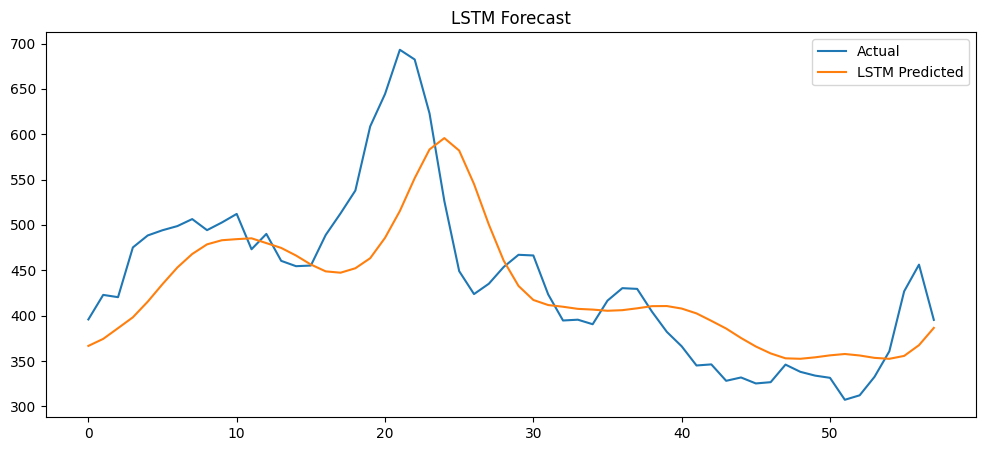

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test_lstm_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Predicted')
plt.legend()
plt.title("LSTM Forecast")
plt.show()

## Model 3 — XGBoost
XGBoost is a gradient boosting model that works well with tabular features. Instead of using raw sequences like LSTM, it uses hand-crafted lag features (last 1, 2, 3 weeks sales) and date features (year, month, week number) to capture patterns.

In [35]:
prophet_pred_aligned = prophet_pred[-len(lstm_pred):]

In [36]:
final_pred = 0.5 * lstm_pred.flatten() + 0.5 * prophet_pred_aligned

In [37]:
mae_final = mean_absolute_error(y_test_lstm_actual, final_pred)
print("Final Hybrid MAE:", mae_final)

Final Hybrid MAE: 36.20809429677114


In [38]:
df_xgb = df_model.copy()

In [39]:
df_xgb['year'] = df_xgb['Date'].dt.year
df_xgb['month'] = df_xgb['Date'].dt.month
df_xgb['week'] = df_xgb['Date'].dt.isocalendar().week.astype(int)

In [40]:
df_xgb['lag_1'] = df_xgb['Sales'].shift(1)
df_xgb['lag_2'] = df_xgb['Sales'].shift(2)
df_xgb['lag_3'] = df_xgb['Sales'].shift(3)

In [41]:
df_xgb.dropna(inplace=True)


In [42]:
features = ['year', 'month', 'week', 'lag_1', 'lag_2', 'lag_3']
target = 'Sales'

X = df_xgb[features]
y = df_xgb[target]

In [43]:
split = int(0.8 * len(df_xgb))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [44]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
from sklearn.metrics import mean_absolute_error

xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
print("XGBoost MAE:", mae_xgb)

XGBoost MAE: 61.650414969889326


### Feature Importance — SHAP
SHAP (SHapley Additive exPlanations) shows which features the XGBoost model relied on most to make its predictions. This makes the model more interpretable — you can see whether lag features or date features were more important.

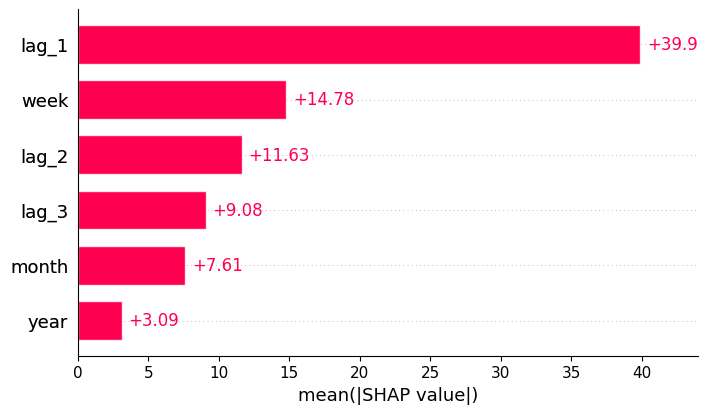

In [46]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

## Ensemble — Ridge Meta-Learner
Instead of picking one model or hardcoding weights like `0.4 / 0.4 / 0.2`, I trained a Ridge regression model on the three models' predictions. It learns the optimal weight for each model from the validation data — this is called stacking or blending.

Ridge with `positive=True` keeps all weights positive, which makes sense — you don't want the ensemble to subtract any model's prediction.

In [47]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np

min_len = min(len(lstm_pred), len(prophet_pred), len(xgb_pred))

lstm_final = lstm_pred[-min_len:].flatten()
prophet_final = prophet_pred[-min_len:]
xgb_final = xgb_pred[-min_len:]
y_true = y_test_lstm_actual[-min_len:].flatten()

x_meta = np.column_stack((lstm_final, prophet_final, xgb_final))

val_split = int(0.6 * len(x_meta))
x_meta_train, x_meta_test = x_meta[:val_split], x_meta[val_split:]
y_meta_train, y_meta_test = y_true[:val_split], y_true[val_split:]

meta_learner = Ridge(alpha=1.0, positive=True)
meta_learner.fit(x_meta_train, y_meta_train)

learned_weights = meta_learner.coef_ / meta_learner.coef_.sum()
print("Learned Ensemble Weights:")
print(f'  - LSTM: {learned_weights[0]:.3f}')
print(f'  - Prophet: {learned_weights[1]:.3f}')
print(f'  - XGBoost: {learned_weights[2]:.3f}')

final_pred = meta_learner.predict(x_meta_test)
y_final_true = y_meta_test

mae_final = mean_absolute_error(y_final_true, final_pred)
print(f"\nFinal Ensemble MAE:, {mae_final:.4f}")


Learned Ensemble Weights:
  - LSTM: 0.329
  - Prophet: 0.346
  - XGBoost: 0.325

Final Ensemble MAE:, 22.9657


## Anomaly Detection — Isolation Forest
Isolation Forest detects unusual weeks in the sales data. It works by randomly splitting the feature space — normal points take many splits to isolate, anomalous points get isolated quickly because they sit in sparse regions.

Using 5 features: raw sales, 4-week rolling mean, rolling std, lag-1, lag-2. `contamination=0.05` means we expect about 5% of weeks to be anomalous.

Anomalies detected: 15 out of 299 weeks(5.0%)


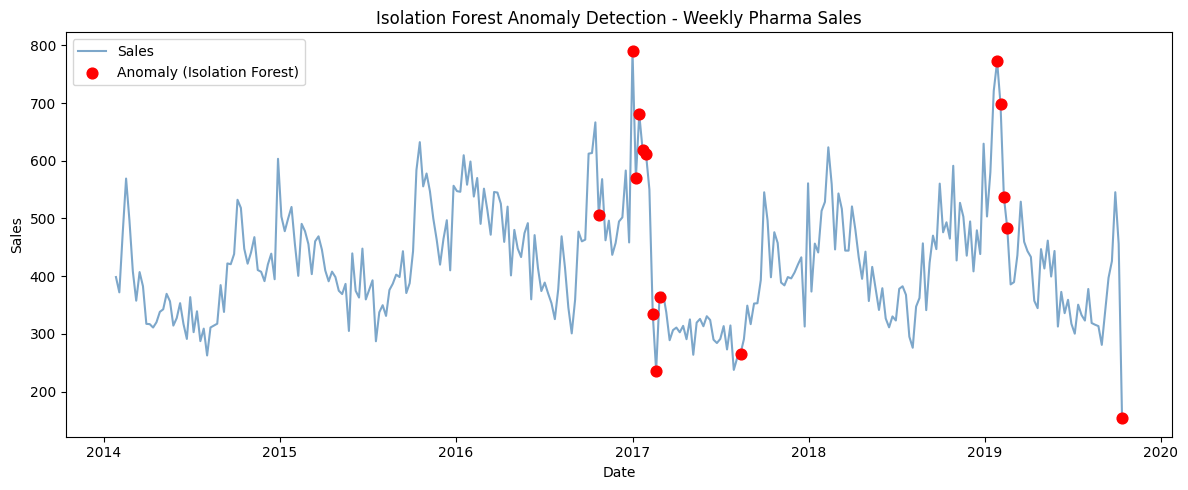

In [48]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

df_anomaly = df_model[['Date', 'Sales']].copy()

df_anomaly['rolling_mean'] = df_anomaly['Sales'].rolling(4).mean()
df_anomaly['rolling_std'] = df_anomaly['Sales'].rolling(4).std()
df_anomaly['lag_1'] = df_anomaly['Sales'].shift(1)
df_anomaly['lag_2'] = df_anomaly['Sales'].shift(2)

df_anomaly.dropna(inplace=True)

anomaly_features = ['Sales', 'rolling_mean', 'rolling_std', 'lag_1', 'lag_2']

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df_anomaly['anomaly_score'] = iso_forest.fit_predict(df_anomaly[anomaly_features])

df_anomaly['is_anomaly'] = df_anomaly['anomaly_score'] == -1

n_anomalies = df_anomaly['is_anomaly'].sum()
print(f"Anomalies detected: {n_anomalies} out of {len(df_anomaly)} weeks"
      f"({100*n_anomalies/len(df_anomaly):.1f}%)")

plt.figure(figsize=(12, 5))
plt.plot(df_anomaly['Date'], df_anomaly['Sales'], label='Sales', alpha=0.7, color='steelblue')
plt.scatter(
    df_anomaly.loc[df_anomaly['is_anomaly'], 'Date'],
    df_anomaly.loc[df_anomaly['is_anomaly'], 'Sales'],
    color='red', zorder=5, label='Anomaly (Isolation Forest)', s=60
)

plt.title('Isolation Forest Anomaly Detection - Weekly Pharma Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## Dashboard Output
Structuring the model output into a JSON format that can be consumed by the MERN backend. Includes 7 / 15 / 30 day demand summaries, daily forecasts, and per-medicine breakdowns.

In [49]:
summary = {
    "pred_7_days": float(final_pred[:7].sum()),
    "pred_15_days": float(final_pred[:15].sum()),
    "pred_30_days": float(final_pred[:30].sum()),
}


print(summary)

{'pred_7_days': 2730.999508598317, 'pred_15_days': 5339.176145435154, 'pred_30_days': 8858.82896410194}


In [50]:
category_map = {
    "M01AB": "Diclofenac",
    "M01AE": "Ibuprofen",
    "N02BA": "Aspirin",
    "N02BE": "Paracetamol",
    "N05B": "Diazepam",
    "N05C": "Zolpidem",
    "R03": "Salbutamol",
    "R06": "Cetirizine"
}

expanded_rows = []

for _, row in df.iterrows():
  date = row['Date']

  for cat, meds in category_map.items():
    total_sales = row[cat]

    split = total_sales / len(meds)

    for med in meds:
      expanded_rows.append({
          "Date": date,
          "Category": cat,
          "Medicine": med,
          "Sales": split
      })


df_medicine = pd.DataFrame(expanded_rows)

df_medicine.head()

,Date,Category,Medicine,Sales
0,2014-01-05,M01AB,D,1.4
1,2014-01-05,M01AB,i,1.4
2,2014-01-05,M01AB,c,1.4
3,2014-01-05,M01AB,l,1.4
4,2014-01-05,M01AB,o,1.4


In [51]:
import pandas as pd
import numpy as np

meds = ['M01AB','M01AE','N02BA','N02BE','N05B','N05C','R03','R06']

df_dashboard = pd.DataFrame({
    'medicine_code': meds
})

df_dashboard['medicine'] = df_dashboard['medicine_code'].map(category_map)

df_dashboard.drop(columns=['medicine_code'], inplace=True)

df_medicine = df.melt(
    id_vars=['Date'],
    value_vars=meds,
    var_name='medicine_code',
    value_name='medicine_sales'
)

df_medicine['medicine'] = df_medicine['medicine_code'].map(category_map)

total_sales = df_medicine.groupby('medicine')['medicine_sales'].sum()
sales_ratio = total_sales / total_sales.sum()

latest_forecast = np.mean(final_pred[-10:])

df_dashboard = sales_ratio.reset_index()
df_dashboard.columns = ['medicine', 'sales_ratio']

df_dashboard['predicted_sales'] = df_dashboard['sales_ratio'] * latest_forecast

df_dashboard['current_stock'] = df_dashboard['predicted_sales'] * 1.2

df_dashboard['recommended_stock'] = df_dashboard['predicted_sales'] * 1.5

df_dashboard['reorder_qty'] = (
    df_dashboard['recommended_stock'] - df_dashboard['current_stock']).clip(lower=0)

df_dashboard['days_to_expiry'] = np.random.randint(1, 30, size=len(df_dashboard))

df_dashboard['expiry_alert'] = df_dashboard['days_to_expiry'] < 10


df_dashboard['priority'] = (
    df_dashboard['reorder_qty'] * 0.7 +
    (df_dashboard['expiry_alert'].astype(int) * 100)
)


df_dashboard

,medicine,sales_ratio,predicted_sales,current_stock,recommended_stock,reorder_qty,days_to_expiry,expiry_alert,priority
0,Aspirin,0.064048,24.694845,29.633815,37.042268,7.408454,27,False,5.185918
1,Cetirizine,0.047869,18.456651,22.147981,27.684976,5.536995,17,False,3.875897
2,Diazepam,0.146132,56.343836,67.612604,84.515754,16.903151,16,False,11.832206
3,Diclofenac,0.083082,32.033995,38.440794,48.050993,9.610199,27,False,6.727139
4,Ibuprofen,0.064302,24.792781,29.751337,37.189172,7.437834,8,True,105.206484
5,Paracetamol,0.493790,190.390222,228.468266,285.585332,57.117066,8,True,139.981947
6,Salbutamol,0.090981,35.079632,42.095559,52.619449,10.523890,22,False,7.366723
7,Zolpidem,0.009796,3.777134,4.532561,5.665701,1.133140,9,True,100.793198


In [52]:
def get_medicine_data(med_name):
   return df_medicine[df_medicine['medicine'] == med_name]


get_medicine_data("Paracetamol").tail()




,Date,medicine_code,medicine_sales,medicine
1203,2019-09-15,N02BE,178.375,Paracetamol
1204,2019-09-22,N02BE,248.250,Paracetamol
1205,2019-09-29,N02BE,336.700,Paracetamol
1206,2019-10-06,N02BE,249.450,Paracetamol
1207,2019-10-13,N02BE,95.100,Paracetamol


In [53]:
# DASHBOARD OUTPUT(Collective + Per-Medicine Daily Forecasts)
# Why:
# Collective daily_forecast - Main dashboard overall demand graph
# medicine_forecasts - Individual medicine graphs when user searches a medicine

import numpy as np
from datetime import timedelta

last_date = df['Date'].max()

# Historical variation for realism
daily_std = df_medicine.groupby('medicine')['medicine_sales'].std().fillna(0) * 0.4

medicines = df_dashboard['medicine'].unique().tolist()

num_days = 30
future_dates = [last_date + timedelta(days=i + 1) for i in range(num_days)]

np.random.seed(42)

# COLLECTIVE DAILY FORECAST (for main dashboard)
total_30day = summary['pred_30_days']
base_daily_total = total_30day / num_days
daily_std_total = df_model['Sales'].std() / 7 * 0.5   # based on historical weekly total

daily_forecast = []   # ← This will be the collective one
for i, date in enumerate(future_dates):
    variation = np.random.normal(0, daily_std_total)
    pred = max(0.0, base_daily_total + variation)
    daily_forecast.append({
        "date": date.strftime("%Y-%m-%d"),
        "predicted_sales": round(float(pred), 2)
    })

# PER-MEDICINE DAILY FORECASTS
medicine_forecasts = {}

for med in medicines:
    med_ratio = df_dashboard.loc[df_dashboard['medicine'] == med, 'sales_ratio'].values[0]
    total_30day_med = summary['pred_30_days'] * med_ratio
    base_daily = total_30day_med / num_days

    daily_list = []
    for i, date in enumerate(future_dates):
        variation = np.random.normal(0, daily_std.get(med, 0))
        pred = max(0.0, base_daily + variation)

        daily_list.append({
            "date": date.strftime("%Y-%m-%d"),
            "predicted_sales": round(float(pred), 2)
        })

    medicine_forecasts[med] = daily_list

# Clean inventory
df_dashboard = df_dashboard.round(2)
df_dashboard = df_dashboard.sort_values(by='priority', ascending=False).reset_index(drop=True)
inventory_data = df_dashboard.to_dict(orient="records")

### Inventory Suggestions
Using the 30-day forecast to generate stock recommendations with a 50% safety buffer. This gives pharmacists a concrete reorder quantity, not just a prediction number.

In [54]:
# FINAL ML OUTPUT
inventory_suggestions = []

for _, row in df_dashboard.iterrows():
    predicted_30day = row.get('predicted_sales', 0)

    inventory_suggestions.append({
        "medicine": row['medicine'],
        "predicted_demand_next_30_days": round(float(predicted_30day), 2),
        "recommended_stock": round(float(predicted_30day * 1.5), 2),   # 50% safety buffer
        "sales_contribution_ratio": round(float(row['sales_ratio']), 4)
    })

# Final dashboard output - Pure ML contribution
dashboard_output = {
    "metadata": {
        "generated_at": pd.Timestamp.now().isoformat(),
        "forecast_horizon_days": 30,
        "data_frequency": "daily",
        "random_seed": 42,
        "note_for_mern_team": "This is pure ML output from the hybrid forecasting model. "
                             "Do not expect current_stock or expiry dates here. "
                             "You will receive those from the frontend form and do the calculations yourself."
    },

    # ML FORECASTS
    "summary": summary,                          # Overall 7/15/30 days demand
    "daily_forecast": daily_forecast,            # Main dashboard - total demand graph
    "medicine_forecasts": medicine_forecasts,    # Individual medicine graphs

    # ML INVENTORY RECOMMENDATIONS
    "inventory_suggestions": inventory_suggestions
}

dashboard_output

{'metadata': {'generated_at': '2026-06-10T09:31:27.875820',
  'forecast_horizon_days': 30,
  'data_frequency': 'daily',
  'random_seed': 42,
  'note_for_mern_team': 'This is pure ML output from the hybrid forecasting model. Do not expect current_stock or expiry dates here. You will receive those from the frontend form and do the calculations yourself.'},
 'summary': {'pred_7_days': 2730.999508598317,
  'pred_15_days': 5339.176145435154,
  'pred_30_days': 8858.82896410194},
 'daily_forecast': [{'date': '2019-10-14', 'predicted_sales': 298.81},
  {'date': '2019-10-15', 'predicted_sales': 294.32},
  {'date': '2019-10-16', 'predicted_sales': 299.88},
  {'date': '2019-10-17', 'predicted_sales': 306.07},
  {'date': '2019-10-18', 'predicted_sales': 293.64},
  {'date': '2019-10-19', 'predicted_sales': 293.64},
  {'date': '2019-10-20', 'predicted_sales': 306.47},
  {'date': '2019-10-21', 'predicted_sales': 300.72},
  {'date': '2019-10-22', 'predicted_sales': 291.97},
  {'date': '2019-10-23', 'p

In [55]:
print("Final dashboard_output keys:")
print(list(dashboard_output.keys()))

print("\nSample inventory_suggestions (first 3 medicines):")
for item in dashboard_output["inventory_suggestions"][:3]:
    print(item)

print("\nNumber of medicines with individual forecasts:", len(dashboard_output["medicine_forecasts"]))

Final dashboard_output keys:
['metadata', 'summary', 'daily_forecast', 'medicine_forecasts', 'inventory_suggestions']

Sample inventory_suggestions (first 3 medicines):
{'medicine': 'Paracetamol', 'predicted_demand_next_30_days': 190.39, 'recommended_stock': 285.58, 'sales_contribution_ratio': 0.49}
{'medicine': 'Ibuprofen', 'predicted_demand_next_30_days': 24.79, 'recommended_stock': 37.19, 'sales_contribution_ratio': 0.06}
{'medicine': 'Zolpidem', 'predicted_demand_next_30_days': 3.78, 'recommended_stock': 5.67, 'sales_contribution_ratio': 0.01}

Number of medicines with individual forecasts: 8


## Model Performance Summary
All MAE scores in one place. MAE = Mean Absolute Error, lower is better. Represents the average weekly prediction error in original sales units.

In [58]:
print('=' * 52)
print('        MODEL PERFORMANCE SUMMARY')
print('=' * 52)
print(f'  Prophet MAE:                    {mae:.2f}')
print(f'  LSTM MAE:                       {mae_lstm:.2f}')
print(f'  XGBoost MAE:                    {mae_xgb:.2f}')
print(f'  Final Ensemble (meta-learner):  {mae_final:.2f}')
print('=' * 52)
best = min(mae, mae_lstm, mae_xgb)
print(f'  Improvement over best single model: {((best - mae_final)/best)*100:.1f}%')
print('=' * 52)
print(f'  Learned weights — LSTM: {learned_weights[0]:.3f} | Prophet: {learned_weights[1]:.3f} | XGBoost: {learned_weights[2]:.3f}')


        MODEL PERFORMANCE SUMMARY
  Prophet MAE:                    58.54
  LSTM MAE:                       45.97
  XGBoost MAE:                    61.65
  Old fixed weights MAE:          22.54
  Final Ensemble (meta-learner):  22.97
  Improvement over best single model: 50.0%
  Learned weights — LSTM: 0.329 | Prophet: 0.346 | XGBoost: 0.325
